In [2]:
# =========================
# CELL 1: SET PATH + LOAD NI TTL
# =========================

import numpy as np
import os

# ---- SET THIS ----
ni_folder = r"C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL"

print("Using NI folder:")
print(ni_folder)

# ---- LOAD FILES ----
timestamps_path = os.path.join(ni_folder, "timestamps.npy")
states_path     = os.path.join(ni_folder, "states.npy")
full_words_path = os.path.join(ni_folder, "full_words.npy")

if not os.path.exists(full_words_path):
    print("❌ TTL files not found")
else:
    timestamps_ni = np.load(timestamps_path)
    states_ni     = np.load(states_path)
    full_words_ni = np.load(full_words_path)

    print("✅ TTL data loaded")
    print("Samples:", len(full_words_ni))
    print("Duration (s):", timestamps_ni[-1] - timestamps_ni[0])

Using NI folder:
C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL
✅ TTL data loaded
Samples: 665277
Duration (s): 3729.392


Rising edges: 3729
Falling edges: 3729
First rising edge at (s): 5.2508

IPI stats:
Mean: 1.000105123390558
Std: 1.2022086112106547e-05


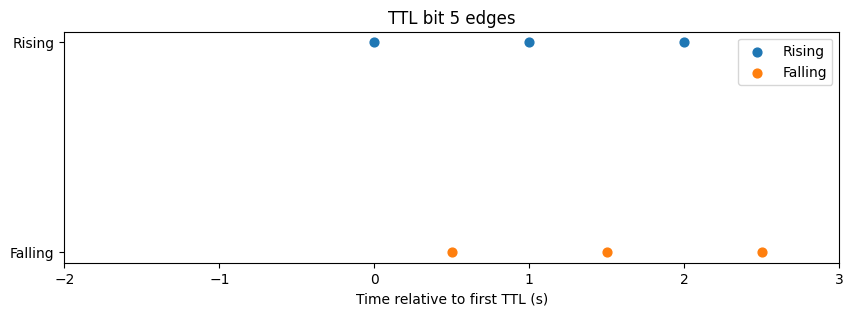

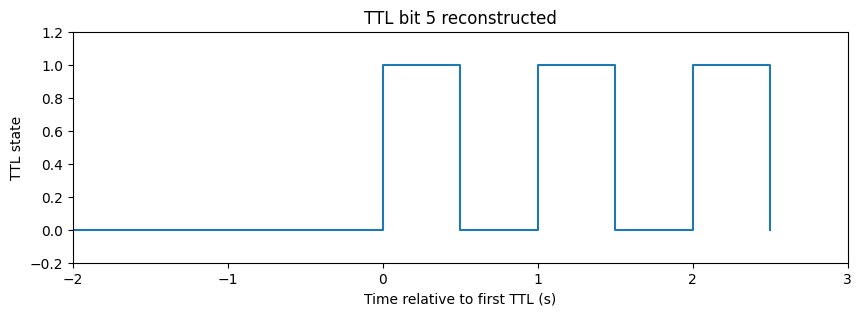

In [5]:
# =========================
# CELL 2: TTL DETECTION + VISUALIZATION
# =========================

import matplotlib.pyplot as plt

# ---- SETTINGS ----
bit = 5          # change TTL line here
window_pre = 2
window_post = 3

mask = 1 << bit

# =========================
# EDGE DETECTION
# =========================
bit_on = (full_words_ni & mask) > 0

bit_on_prev = np.roll(bit_on, 1)
bit_on_prev[0] = False

rising_idx  = (~bit_on_prev) & (bit_on)
falling_idx = (bit_on_prev) & (~bit_on)

rising_times  = timestamps_ni[rising_idx]
falling_times = timestamps_ni[falling_idx]

# =========================
# BASIC INFO
# =========================
print("Rising edges:", len(rising_times))
print("Falling edges:", len(falling_times))

if len(rising_times) == 0:
    print("❌ No rising edges found.")

else:
    first_event = rising_times[0]
    print("First rising edge at (s):", first_event)

    # ---- IPI check (this is important for your sync validation) ----
    if len(rising_times) > 1:
        ipi = np.diff(rising_times)
        print("\nIPI stats:")
        print("Mean:", np.mean(ipi))
        print("Std:", np.std(ipi))

    # ---- window ----
    t_ref = first_event
    t0 = t_ref - window_pre
    t1 = t_ref + window_post

    # =========================
    # SCATTER PLOT
    # =========================
    mask_r = (rising_times > t0) & (rising_times < t1)
    mask_f = (falling_times > t0) & (falling_times < t1)

    rising_rel  = rising_times[mask_r] - t_ref
    falling_rel = falling_times[mask_f] - t_ref

    plt.figure(figsize=(10, 3))

    plt.scatter(rising_rel,  [1]*len(rising_rel),  s=40, label="Rising")
    plt.scatter(falling_rel, [0]*len(falling_rel), s=40, label="Falling")

    plt.yticks([0, 1], ["Falling", "Rising"])
    plt.xlabel("Time relative to first TTL (s)")
    plt.title(f"TTL bit {bit} edges")
    plt.xlim(-window_pre, window_post)
    plt.legend()

    plt.show()

    # =========================
    # SQUARE WAVE
    # =========================
    times  = np.concatenate([rising_times, falling_times])
    values = np.concatenate([np.ones_like(rising_times), np.zeros_like(falling_times)])

    order = np.argsort(times)
    times  = times[order]
    values = values[order]

    mask_window = (times > t0) & (times < t1)
    times_w  = times[mask_window]
    values_w = values[mask_window]

    prev_state = 0
    earlier = times < t0
    if np.any(earlier):
        prev_state = values[np.where(earlier)[0][-1]]

    times_plot  = np.insert(times_w, 0, t0) - t_ref
    values_plot = np.insert(values_w, 0, prev_state)

    plt.figure(figsize=(10, 3))
    plt.step(times_plot, values_plot, where='post')

    plt.ylim(-0.2, 1.2)
    plt.xlabel("Time relative to first TTL (s)")
    plt.ylabel("TTL state")
    plt.title(f"TTL bit {bit} reconstructed")
    plt.xlim(-window_pre, window_post)

    plt.show()

Showing trials: [1, 2, 3, 4, 5]
Master reference: trial 3


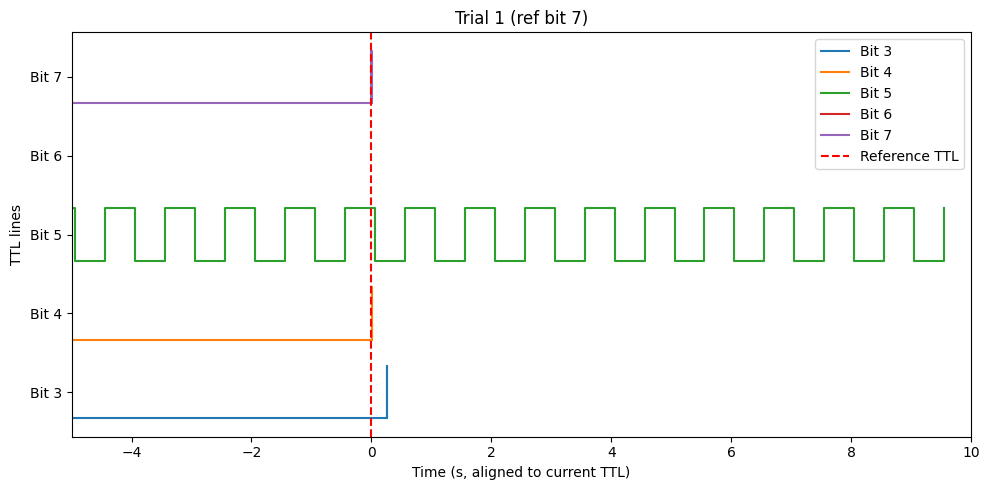

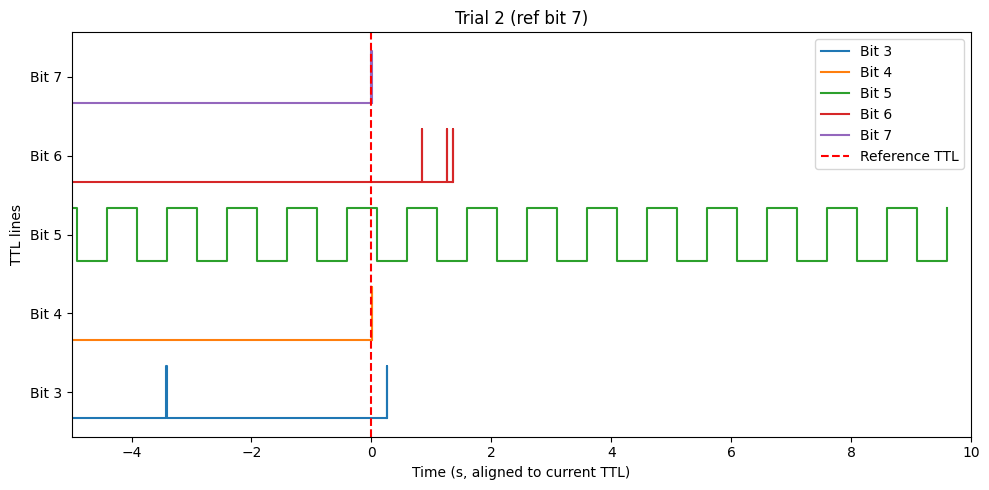

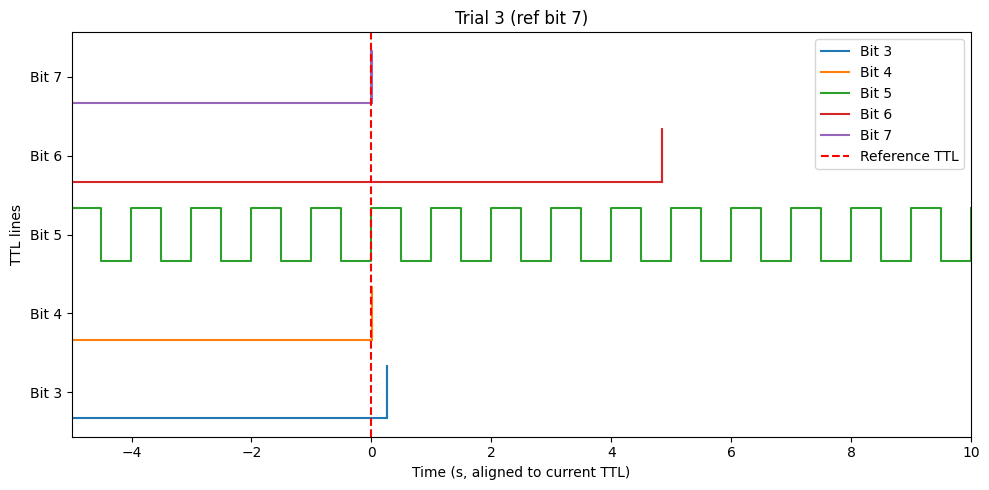

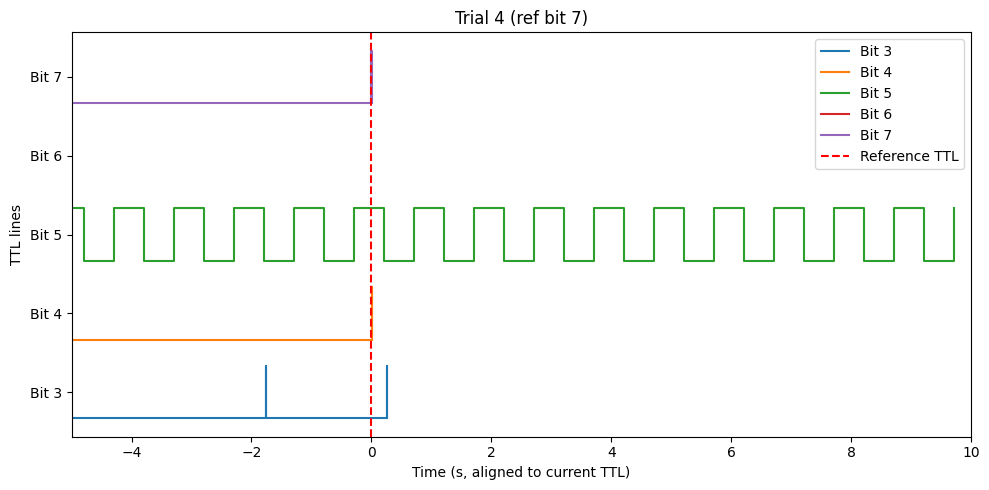

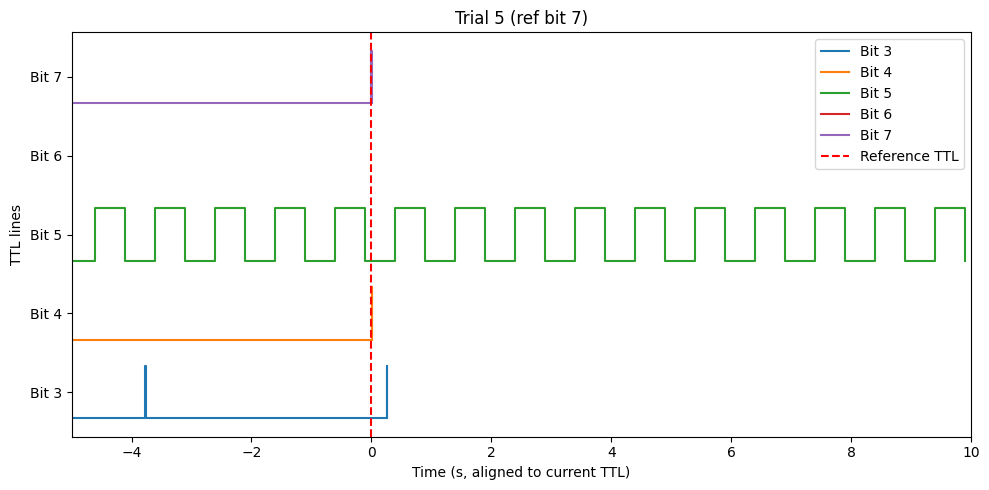

In [4]:
# =========================
# CELL 3: MULTI-TRIAL TTL VISUALIZATION (PINS 3–7)
# =========================

import matplotlib.pyplot as plt
import numpy as np

# ---- SETTINGS ----
bits_to_plot = [3, 4, 5, 6, 7]
ref_bit = 7

trial_index = 3      # ← master reference (0-based)
n_surround = 5       # ← number of neighboring TTLs to include

window_pre = 5
window_post = 10

# =========================
# GET REFERENCE TTLs
# =========================
mask_ref = 1 << ref_bit

bit_on_ref = (full_words_ni & mask_ref) > 0
bit_on_prev_ref = np.roll(bit_on_ref, 1)
bit_on_prev_ref[0] = False

rising_ref_idx = (~bit_on_prev_ref) & (bit_on_ref)
rising_ref_times = timestamps_ni[rising_ref_idx]

n_total = len(rising_ref_times)

if n_total == 0:
    print("❌ No TTLs found on reference bit")

else:
    # ---- determine which trials to plot ----
    start = max(0, trial_index - n_surround // 2)
    end   = min(n_total, trial_index + n_surround // 2 + 1)

    trial_indices = list(range(start, end))

    print(f"Showing trials: {trial_indices}")
    print(f"Master reference: trial {trial_index}")

    # =========================
    # LOOP OVER SELECTED TRIALS
    # =========================
    for trial_i in trial_indices:

        t_ref = rising_ref_times[trial_i]

        t0 = t_ref - window_pre
        t1 = t_ref + window_post

        plt.figure(figsize=(10, 5))

        # ---- loop over TTL bits ----
        for j, bit in enumerate(bits_to_plot):

            mask = 1 << bit
            bit_on = (full_words_ni & mask) > 0

            bit_on_prev = np.roll(bit_on, 1)
            bit_on_prev[0] = False

            rising_idx  = (~bit_on_prev) & (bit_on)
            falling_idx = (bit_on_prev) & (~bit_on)

            rising_times  = timestamps_ni[rising_idx]
            falling_times = timestamps_ni[falling_idx]

            # combine transitions
            times  = np.concatenate([rising_times, falling_times])
            values = np.concatenate([np.ones_like(rising_times), np.zeros_like(falling_times)])

            order = np.argsort(times)
            times  = times[order]
            values = values[order]

            # window selection
            mask_window = (times > t0) & (times < t1)
            times_w  = times[mask_window]
            values_w = values[mask_window]

            # previous state
            prev_state = 0
            earlier = times < t0
            if np.any(earlier):
                prev_state = values[np.where(earlier)[0][-1]]

            times_plot  = np.insert(times_w, 0, t0) - t_ref
            values_plot = np.insert(values_w, 0, prev_state)

            offset = j * 1.5

            plt.step(times_plot, values_plot + offset, where='post', label=f"Bit {bit}")

        # ---- formatting ----
        plt.axvline(0, color='red', linestyle='--', label='Reference TTL')

        plt.xlabel("Time (s, aligned to current TTL)")
        plt.ylabel("TTL lines")
        plt.title(f"Trial {trial_i} (ref bit {ref_bit})")

        plt.yticks([k * 1.5 + 0.5 for k in range(len(bits_to_plot))],
                   [f"Bit {b}" for b in bits_to_plot])

        plt.xlim(-window_pre, window_post)
        plt.legend(loc='upper right')

        plt.tight_layout()
        plt.show()